# Fully-Connected Autoencoder with 3D Latent Space

Same architecture as `01_FC_Autoencoder_2D.ipynb` but with **3 latent dimensions**.
Three dims still fit on a scatter plot, give us a richer latent space than 2D.

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

BATCH_SIZE = 256
EPOCHS = 30
LR = 1e-3
LATENT_DIM = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
to_tensor = transforms.ToTensor()
train_ds = datasets.MNIST("data", train=True, download=True, transform=to_tensor)
test_ds = datasets.MNIST("data", train=False, download=True, transform=to_tensor)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Train: {len(train_ds)}, Test: {len(test_ds)}")

Train: 60000, Test: 10000


## 1. Model: Fully-Connected Autoencoder, 3D Latent

- Encoder: 784 → 256 → 64 → **3**
- Decoder: **3** → 64 → 256 → 784 (sigmoid)

In [4]:
class FCAutoencoder(nn.Module):
    def __init__(self, latent_dim=3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256), nn.ReLU(),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, 256), nn.ReLU(),
            nn.Linear(256, 28 * 28), nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z).view(-1, 1, 28, 28)
        return out, z

model = FCAutoencoder(LATENT_DIM).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
x = torch.randn(1, 1, 28, 28).to(device)
out, z = model(x)
print(f"Input: {x.shape}  ->  Latent: {z.shape}  ->  Output: {out.shape}")

Parameters: 435,987
Input: torch.Size([1, 1, 28, 28])  ->  Latent: torch.Size([1, 3])  ->  Output: torch.Size([1, 1, 28, 28])


## 2. Train

In [5]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {"train": [], "val": []}
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for images, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False):
        images = images.to(device)
        recon, _ = model(images)
        loss = criterion(recon, images)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            recon, _ = model(images)
            val_loss += criterion(recon, images).item()

    train_loss /= len(train_loader)
    val_loss /= len(test_loader)
    history["train"].append(train_loss)
    history["val"].append(val_loss)
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

torch.save(model.state_dict(), "fc_autoencoder_3d.pth")
print("Saved to fc_autoencoder_3d.pth")

Epoch 1: Train Loss=0.2646, Val Loss=0.2090


Epoch 2: Train Loss=0.1988, Val Loss=0.1906


Epoch 3: Train Loss=0.1853, Val Loss=0.1795


Epoch 4: Train Loss=0.1772, Val Loss=0.1744


Epoch 5: Train Loss=0.1732, Val Loss=0.1718


...

Epoch 26: Train Loss=0.1547, Val Loss=0.1576


Epoch 27: Train Loss=0.1543, Val Loss=0.1574


Epoch 28: Train Loss=0.1540, Val Loss=0.1570


Epoch 29: Train Loss=0.1537, Val Loss=0.1570


Epoch 30: Train Loss=0.1535, Val Loss=0.1568
Saved to fc_autoencoder_3d.pth


## 3. Reconstruction Quality

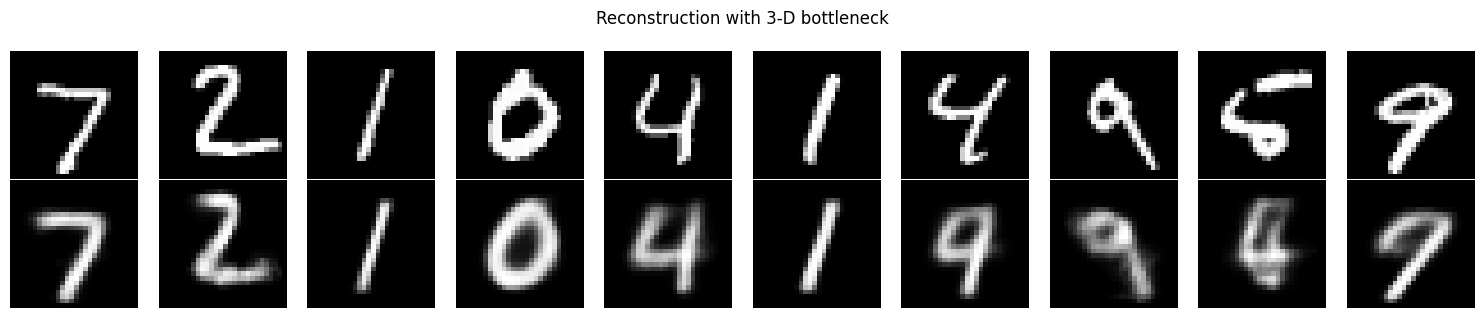

In [6]:
model.eval()
images, _ = next(iter(test_loader))
images = images[:10].to(device)
with torch.no_grad():
    recons, _ = model(images)

fig, axes = plt.subplots(2, 10, figsize=(15, 3.2))
for i in range(10):
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(recons[i].cpu().squeeze(), cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("Reconstruction", fontsize=11)
plt.suptitle(f"Reconstruction with {LATENT_DIM}-D bottleneck", fontsize=12)
plt.tight_layout()
plt.show()

## 4. The 3D Latent Space

Encode the entire test set and plot every point in 3D, colored by digit class.

In [7]:
all_z, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        _, z = model(images.to(device))
        all_z.append(z.cpu()); all_labels.append(labels)
all_z = torch.cat(all_z).numpy()
all_labels = torch.cat(all_labels).numpy()

for i in range(LATENT_DIM):
    print(f"z{i+1}: range [{all_z[:, i].min():.2f}, {all_z[:, i].max():.2f}], "
          f"mean={all_z[:, i].mean():.2f}, std={all_z[:, i].std():.2f}")

z1: range [-15.93, 16.91], mean=-0.90, std=4.34
z2: range [-42.81, 9.16], mean=-5.25, std=6.11
z3: range [-15.62, 19.47], mean=-0.17, std=5.54


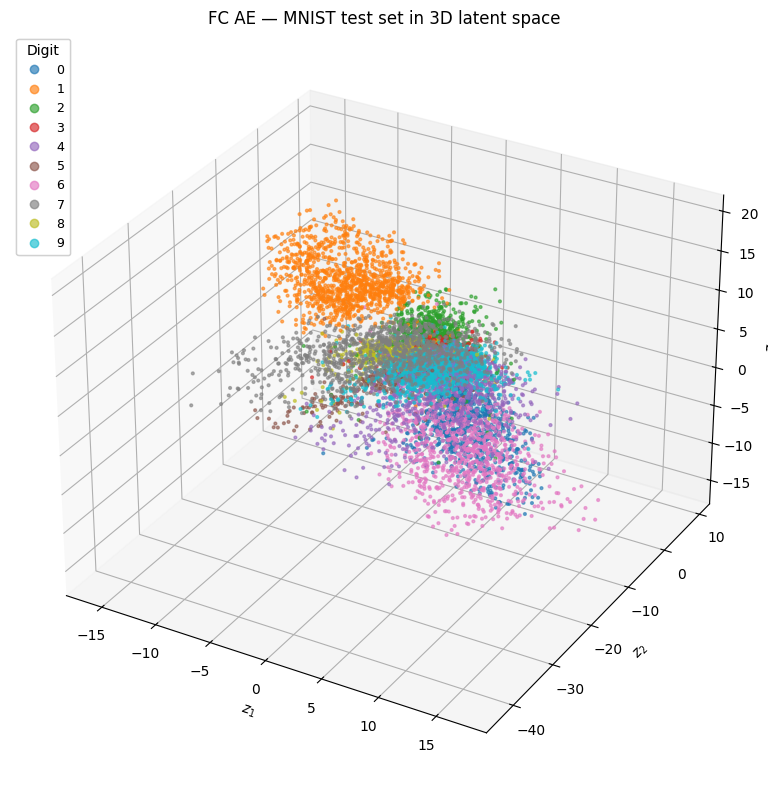

In [8]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(all_z[:, 0], all_z[:, 1], all_z[:, 2],
                     c=all_labels, cmap="tab10", s=4, alpha=0.6)
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$"); ax.set_zlabel("$z_3$")
ax.set_title("FC AE — MNIST test set in 3D latent space")
legend = ax.legend(*scatter.legend_elements(), title="Digit", loc="upper left", fontsize=9)
ax.add_artist(legend)
plt.tight_layout()
plt.show()

### Pairwise 2D Projections

Three 2D projections of the same scatter — easier to read than the 3D view.

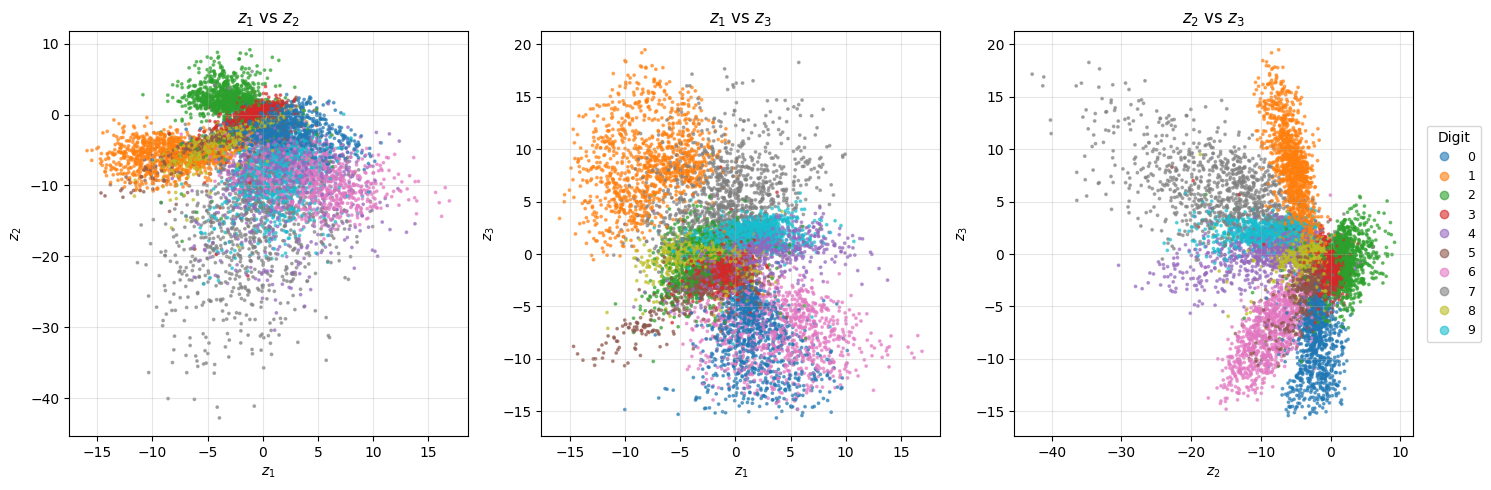

In [9]:
pairs = [(0, 1), (0, 2), (1, 2)]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (i, j) in zip(axes, pairs):
    sc = ax.scatter(all_z[:, i], all_z[:, j], c=all_labels, cmap="tab10", s=3, alpha=0.6)
    ax.set_xlabel(f"$z_{i+1}$"); ax.set_ylabel(f"$z_{j+1}$")
    ax.set_title(f"$z_{i+1}$ vs $z_{j+1}$")
    ax.grid(alpha=0.3)
axes[-1].legend(*sc.legend_elements(), title="Digit", loc="center left",
                bbox_to_anchor=(1.02, 0.5), fontsize=9)
plt.tight_layout()
plt.show()

## 5. Random Sampling

Same failure mode as before

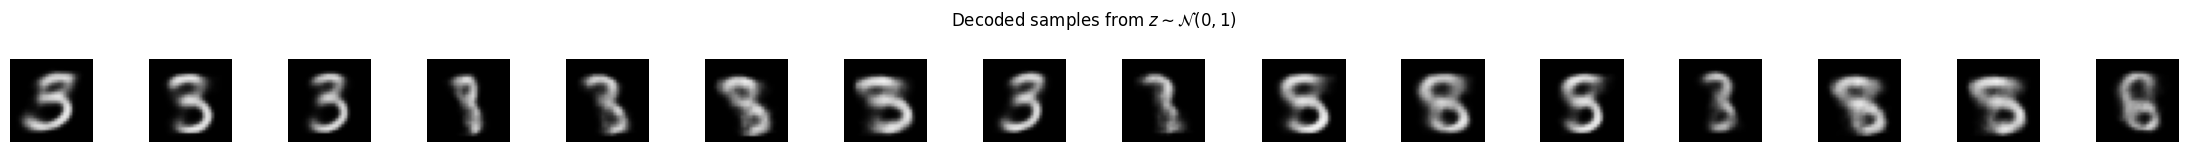

In [10]:
torch.manual_seed(0)
N = 16

z_gauss = torch.randn(N, LATENT_DIM, device=device)
with torch.no_grad():
    samples_gauss = model.decoder(z_gauss).view(-1, 28, 28).cpu()

fig, axes = plt.subplots(1, N, figsize=(1.4 * N, 1.5))
for j in range(N):
    axes[j].imshow(samples_gauss[j], cmap="gray", vmin=0, vmax=1); axes[j].axis("off")
fig.suptitle("Decoded samples from $z \\sim \\mathcal{N}(0, 1)$", fontsize=12)
plt.tight_layout()
plt.show()

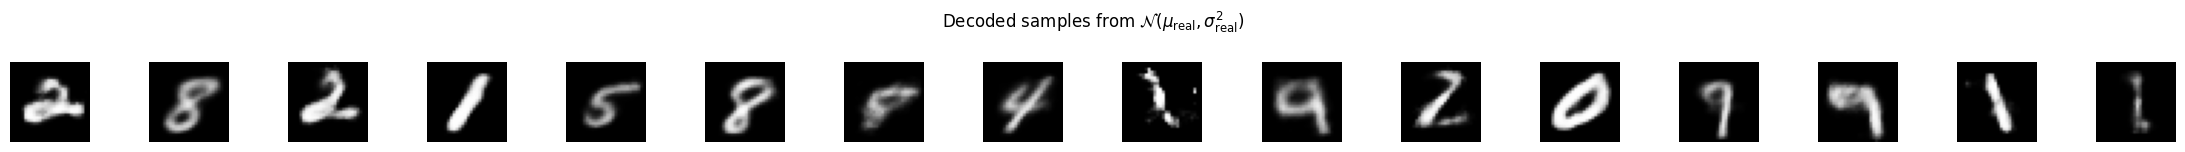

In [11]:
torch.manual_seed(1)

mu_real = torch.tensor(all_z.mean(axis=0), dtype=torch.float32, device=device)
sigma_real = torch.tensor(all_z.std(axis=0), dtype=torch.float32, device=device)
z_matched = mu_real + sigma_real * torch.randn(N, LATENT_DIM, device=device)

with torch.no_grad():
    samples_matched = model.decoder(z_matched).view(-1, 28, 28).cpu()

fig, axes = plt.subplots(1, N, figsize=(1.4 * N, 1.5))
for j in range(N):
    axes[j].imshow(samples_matched[j], cmap="gray", vmin=0, vmax=1); axes[j].axis("off")
fig.suptitle("Decoded samples from $\\mathcal{N}(\\mu_{\\text{real}}, \\sigma_{\\text{real}}^2)$", fontsize=12)
plt.tight_layout()
plt.show()

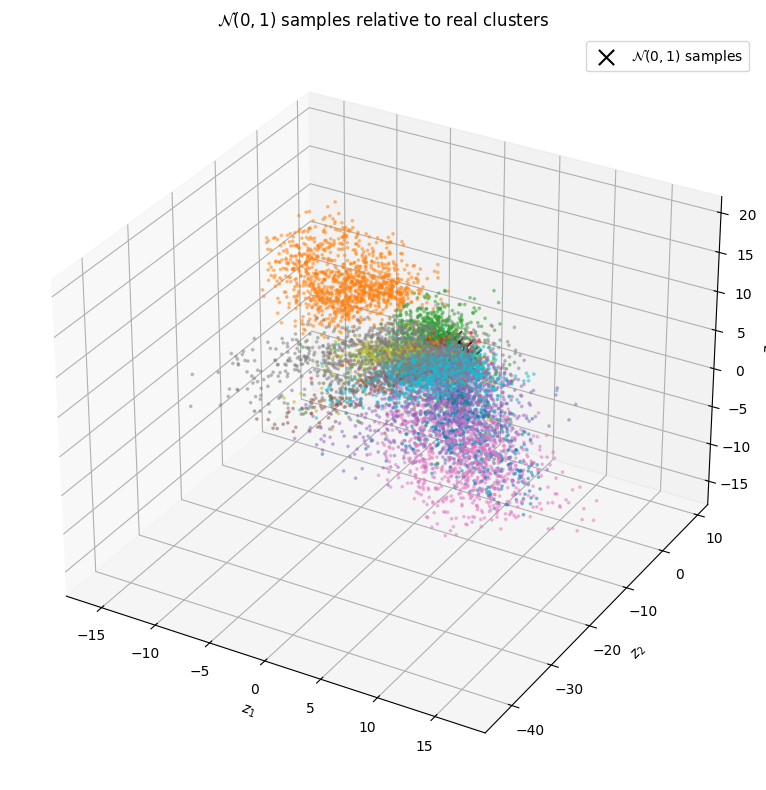

In [12]:
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(all_z[:, 0], all_z[:, 1], all_z[:, 2], c=all_labels, cmap="tab10", s=3, alpha=0.4)
ax.scatter(z_gauss.cpu()[:, 0], z_gauss.cpu()[:, 1], z_gauss.cpu()[:, 2],
           c="black", s=120, marker="x", label="$\\mathcal{N}(0, 1)$ samples")
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$"); ax.set_zlabel("$z_3$")
ax.set_title("$\\mathcal{N}(0, 1)$ samples relative to real clusters")
ax.legend()
plt.tight_layout()
plt.show()

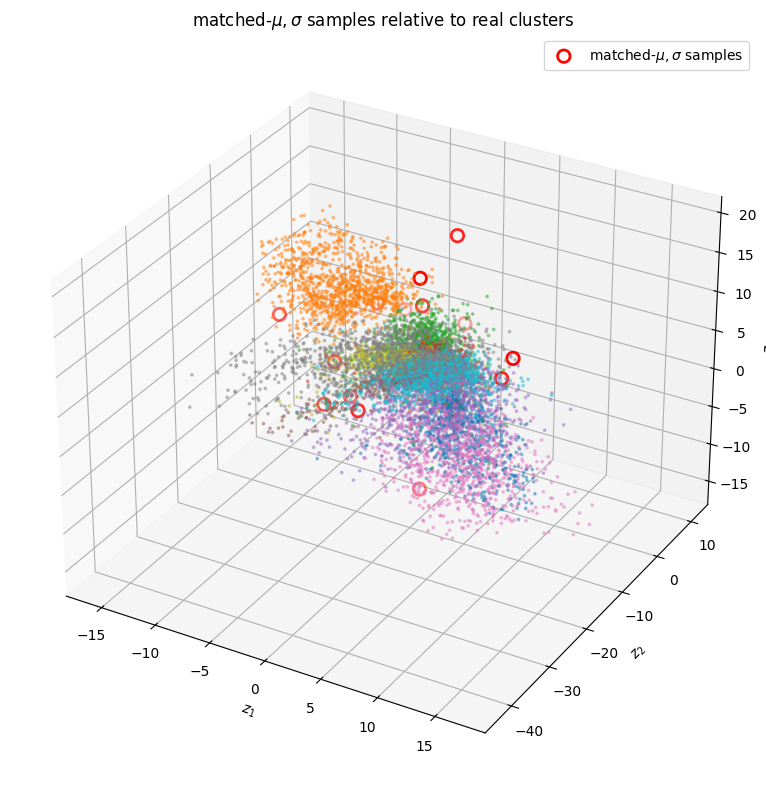

In [13]:
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(all_z[:, 0], all_z[:, 1], all_z[:, 2], c=all_labels, cmap="tab10", s=3, alpha=0.4)
ax.scatter(z_matched.cpu()[:, 0], z_matched.cpu()[:, 1], z_matched.cpu()[:, 2],
           facecolors="none", edgecolors="red", s=80, linewidths=2,
           label="matched-$\\mu, \\sigma$ samples")
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$"); ax.set_zlabel("$z_3$")
ax.set_title("matched-$\\mu, \\sigma$ samples relative to real clusters")
ax.legend()
plt.tight_layout()
plt.show()

## Save Latents for Comparison

Save the encoded latents and labels so the VAE notebook can plot them on the same axes.

In [14]:
np.savez("latents_ae_3d.npz", z=all_z, labels=all_labels)
print("Saved latents_ae_3d.npz")

Saved latents_ae_3d.npz
